In [1]:
suppressWarnings(suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(cowplot)
  library(ggtext)
  library(gt)
}))

## Define plot parameters

In [2]:
metric_order <- c(
  "dists",
  "lpips",
  "foreground_ssim",
  "ssim",
  "foreground_psnr",
  "psnr",
  "mae"
 )

metric_labels <- c(
  "dists" = "<span style='color:#3B4CC0'>DISTS</span>",
  "lpips" = "<span style='color:#3B4CC0'>LPIPS</span>",
  "foreground_ssim" = "<span style='color:#F1A340'>Foreground SSIM</span>",
  "ssim" = "<span style='color:#F1A340'>SSIM</span>",
  "foreground_psnr" = "<span style='color:#F1A340'>Foreground PSNR</span>",
  "psnr" = "<span style='color:#F1A340'>PSNR</span>",
  "mae" = "<span style='color:#7F7F7F'>MAE</span>"
 )

ablation_order <- c(
  "Dilate",
  "Erode",
  "GaussianBlur",
  "GaussNoise",
  "GridDistortion",
  "RandomGamma"
 )

confounder_order <- c(
  "Cell line",
  "Seeding density / confluence"
 )

## Read in plot data

In [3]:
cell_summary <- read_csv(
  "results/boot_nest_cell_line_summary.csv",
  show_col_types = FALSE
) %>%
  mutate(confounder = "Cell line")

confluence_summary <- read_csv(
  "results/boot_nest_confluence_summary.csv",
  show_col_types = FALSE
) %>%
  mutate(confounder = "Seeding density / confluence")

summary_df <- bind_rows(cell_summary, confluence_summary) %>%
  mutate(
    metric_name = factor(metric_name, levels = metric_order),
    confounder = factor(confounder, levels = confounder_order)
  )

## Divide partial r squared by restricted r squared to yield surrogate of burden - ratio of metric measurement of confouding factor vs metric measurement of ablation extent

In [4]:
eps <- 1e-4

compute_burden_df <- function(df, confounder_label) {
  df %>%
    mutate(
      confounder = confounder_label,
      burden = (partial_r2_mean + eps) / (restricted_r2_mean + eps),
      metric_name = factor(metric_name, levels = rev(metric_order)),
      ablation_type = factor(ablation_type, levels = ablation_order)
    )
}

cell_burden_df <- compute_burden_df(cell_summary, "Cell line")
confluence_burden_df <- compute_burden_df(confluence_summary, "Seeding density / confluence")

burden_df <- bind_rows(cell_burden_df, confluence_burden_df)
head(burden_df)

metric_name,ablation_type,n_boot,restricted_r2_mean,restricted_r2_lower,restricted_r2_upper,partial_r2_mean,partial_r2_lower,partial_r2_upper,confounder,burden
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
dists,Dilate,300,0.3331456,0.3225113,0.3443324,0.05603761,0.04934570,0.06247679,Cell line,0.16845719
dists,Erode,300,0.4487213,0.4381954,0.4594749,0.06848759,0.06253354,0.07485098,Cell line,0.15281715
dists,GaussNoise,300,0.1122503,0.1042769,0.1211783,0.03494544,0.03044147,0.04150259,Cell line,0.31193008
dists,GaussianBlur,300,0.1701987,0.1612749,0.1799393,0.03358692,0.02862447,0.03901237,Cell line,0.19781073
dists,GridDistortion,300,0.6723556,0.6649866,0.6798057,0.03051835,0.02557481,0.03557358,Cell line,0.04553215
dists,RandomGamma,300,0.2024107,0.1941798,0.2101991,0.01819085,0.01578900,0.02063806,Cell line,0.09032043


In [5]:
max_abs_burden <- max(abs(burden_df$burden), na.rm = TRUE)
fill_limit <- ceiling(max_abs_burden)

## Plotting helpers

In [6]:
plot_burden_heatmap <- function(
  df,
  title,
  show_y = TRUE,
  show_legend = TRUE,
  fill_limit = NULL,
  plot_margin = margin(5.5, 5.5, 5.5, 5.5)
) {
  p <- ggplot(
    df,
    aes(
      x = ablation_type,
      y = metric_name,
      fill = burden
    )
  ) +
    geom_tile(color = "white", linewidth = 0.6) +
    scale_y_discrete(labels = metric_labels, position = "right") +
    labs(
      title = title,
      x = "Degradation transform",
      y = NULL,
      fill = expression("(partial R"^2~"/ restricted R"^2*")")
    ) +
    theme_bw(base_size = 11) +
    theme(
      panel.grid = element_blank(),
      plot.title = element_text(size = 11, face = "bold", hjust = 0),
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
      axis.text.y = element_text(size = 9.5),
      legend.position = "right",
      legend.title = element_text(size = 9),
      legend.text = element_text(size = 8.5),
      plot.margin = plot_margin
    )

  if (!is.null(fill_limit)) {
    p <- p +
      scale_fill_gradient2(
        low = "#2166AC",
        mid = "white",
        high = "#B2182B",
        midpoint = 0,
        limits = c(-fill_limit, fill_limit),
        oob = scales::squish
      )
  } else {
    p <- p +
      scale_fill_gradient2(
        low = "#2166AC",
        mid = "white",
        high = "#B2182B",
        midpoint = 0
      )
  }

  if (!show_y) {
    p <- p + theme(
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  }

  if (!show_legend) {
    p <- p + guides(fill = "none")
  }

  p
}

## Plot burden heatmap for two confounder factors and combine as single panel

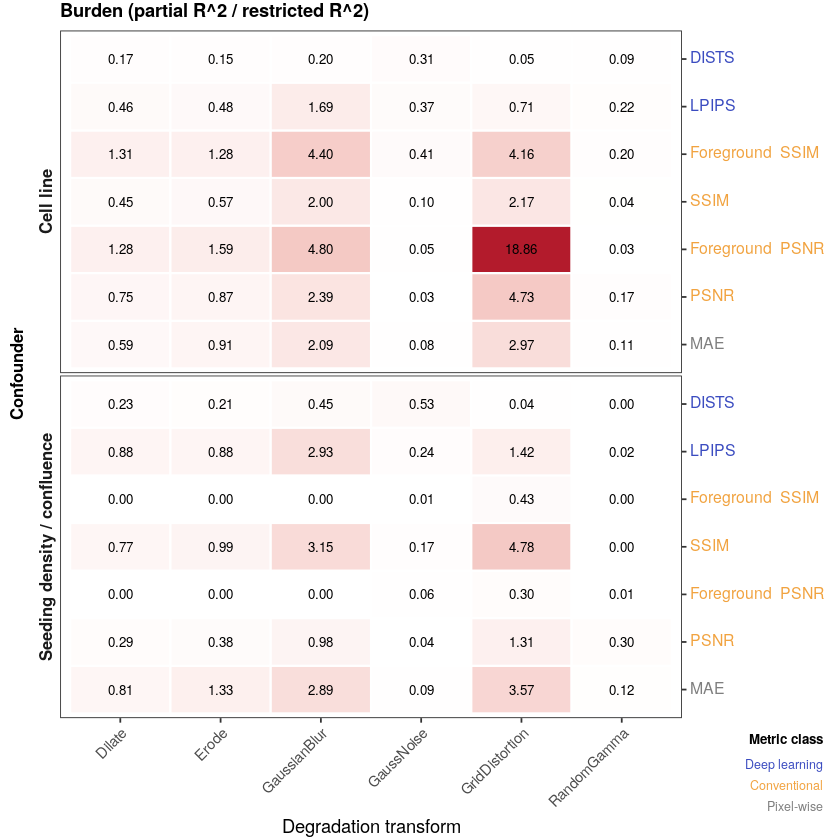

In [7]:
p_burden_facet_base <- ggplot(
  burden_df,
  aes(
    x = ablation_type,
    y = metric_name,
    fill = burden
  )
 ) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(
    aes(label = sprintf("%.2f", burden)),
    size = 2.8,
    color = "black"
  ) +
  scale_y_discrete(labels = metric_labels, position = "right") +
  facet_grid(confounder ~ ., switch = "y") +
  labs(
    title = "Burden (partial R^2 / restricted R^2)",
    x = "Degradation transform",
    y = NULL
  ) +
  theme_bw(base_size = 11) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = ggtext::element_markdown(size = 9.5),
    plot.title = element_text(size = 11, face = "bold", hjust = 0),
    strip.placement = "outside",
    strip.background = element_blank(),
    strip.text.y.left = element_text(angle = 90, face = "bold", size = 10),
    panel.spacing.y = unit(0.1, "lines"),
    legend.position = "none",
    plot.margin = margin(2, 8, 2, 18)
  )

if (!is.null(fill_limit)) {
  p_burden_facet_base <- p_burden_facet_base +
    scale_fill_gradient2(
      low = "#2166AC",
      mid = "white",
      high = "#B2182B",
      midpoint = 0,
      limits = c(-fill_limit, fill_limit),
      oob = scales::squish
    )
} else {
  p_burden_facet_base <- p_burden_facet_base +
    scale_fill_gradient2(
      low = "#2166AC",
      mid = "white",
      high = "#B2182B",
      midpoint = 0
    )
}

p_burden_facet_labeled <- cowplot::ggdraw(p_burden_facet_base) +
  cowplot::draw_label(
    "Confounder",
    x = 0.02,
    y = 0.5,
    angle = 90,
    vjust = 0.5,
    hjust = 0,
    fontface = "bold",
    size = 10
  )

panel_C <- cowplot::ggdraw(p_burden_facet_labeled) +
  cowplot::draw_label(
    "Metric class",
    x = 0.98,
    y = 0.12,
    hjust = 1,
    size = 8,
    fontface = "bold"
  ) +
  cowplot::draw_label(
    "Deep learning",
    x = 0.98,
    y = 0.09,
    hjust = 1,
    size = 7.5,
    color = "#3B4CC0"
  ) +
  cowplot::draw_label(
    "Conventional",
    x = 0.98,
    y = 0.065,
    hjust = 1,
    size = 7.5,
    color = "#F1A340"
  ) +
  cowplot::draw_label(
    "Pixel-wise",
    x = 0.98,
    y = 0.04,
    hjust = 1,
    size = 7.5,
    color = "#7F7F7F"
  )

panel_C

In [8]:
ggsave(
  filename = "plots/fig_panels/panel_C_confounder_burden_v.pdf",
  plot = panel_C,
  width = 6,
  height = 10,
  units = "in",
  device = cairo_pdf,
  create.dir = TRUE
)

ggsave(
  filename = "plots/fig_panels/panel_C_confounder_burden_v.png",
  plot = panel_C,
  width = 6,
  height = 10,
  units = "in",
  dpi = 300,
  create.dir = TRUE
)

## Make high level summary plot for which metrics have lowest burden across the board

In [9]:
min_burden_winners <- burden_df %>%
  group_by(confounder, ablation_type) %>%
  filter(burden == min(burden, na.rm = TRUE)) %>%
  ungroup()

min_burden_counts <- min_burden_winners %>%
  count(metric_name, name = "n_min") %>%
  right_join(tibble(metric_name = factor(metric_order, levels = metric_order)),
    by = "metric_name"
  ) %>%
  mutate(
    n_min = ifelse(is.na(n_min), 0, n_min),
    metric_label = metric_labels[as.character(metric_name)],
    stars = strrep("*", n_min)
  )

min_burden_table <- min_burden_counts %>%
  select(metric_label, stars) %>%
  as.data.frame()

row.names(min_burden_table) <- min_burden_table$metric_label
min_burden_table$metric_label <- NULL

min_burden_table

,stars
,<chr>
<span style='color:#F1A340'>PSNR</span>,*
<span style='color:#F1A340'>Foreground PSNR</span>,***
<span style='color:#F1A340'>Foreground SSIM</span>,**
<span style='color:#3B4CC0'>DISTS</span>,******
<span style='color:#3B4CC0'>LPIPS</span>,
<span style='color:#F1A340'>SSIM</span>,
<span style='color:#7F7F7F'>MAE</span>,


In [10]:
min_burden_gt <- min_burden_table %>%
  tibble::rownames_to_column("metric_label") %>%
  gt::gt() %>%
  gt::fmt_markdown(columns = "metric_label") %>%
  gt::cols_label(
    metric_label = "Metric",
    stars = "Min burden count"
  ) %>%
  gt::tab_options(
    table.font.size = 10,
    data_row.padding = gt::px(2)
  )

min_burden_gt

ERROR while rich displaying an object: Error in names(res) <- prefix: 'names' attribute [1] must be the same length as the vector [0]

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_html.l

<div id="veeoxxgrpc" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>html {
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Oxygen, Ubuntu, Cantarell, 'Helvetica Neue', 'Fira Sans', 'Droid Sans', Arial, sans-serif;
}

#veeoxxgrpc .gt_table {
  display: table;
  border-collapse: collapse;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 10px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#veeoxxgrpc .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  

In [11]:
gt::gtsave(
  data = min_burden_gt,
  filename = "plots/fig_panels/panel_C_min_burden_table.html"
 )